In [1]:
import os
import glob
import re
import cv2
import numpy as np
import pandas as pd
import gc
import matplotlib.pyplot as plt
import kagglehub
from pathlib import Path
from joblib import Parallel, delayed

In [36]:
DATA_DIR = Path("./data")
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed_pairs"

RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [37]:
dataset_path = kagglehub.dataset_download(
    "isaienkov/deforestation-in-ukraine",
    output_dir=str(RAW_DIR)
)

In [38]:
# Search for all image files in the downloaded folder
all_files = glob.glob(os.path.join(dataset_path, "**", "*.png"), recursive=True) + \
            glob.glob(os.path.join(dataset_path, "**", "*.jpg"), recursive=True) + \
            glob.glob(os.path.join(dataset_path, "**", "*.tif"), recursive=True) + \
            glob.glob(os.path.join(dataset_path, "**", "*.jp2"), recursive=True) 

# Filtering unnecessary graphic files (banners, logos, avatars)
blacklist = ['banner', 'logo', 'header', 'preview', 'icon', 'thumb', 'mask', 'metadata']
satellite_images = [
    f for f in all_files 
    if not any(bad in Path(f).name.lower() for bad in blacklist)
    and "TCI" in Path(f).name 
]

In [39]:
satellite_images.sort()
pairs = []

# Regular expression for searching for Sentinel-2 Tile ID (e.g. T35UQP)
tile_pattern = re.compile(r'(T\d{2}[A-Z]{3})')

groups = {}
for f in satellite_images:
    match = tile_pattern.search(Path(f).name)
    group_key = match.group(1) if match else "region_all"
    groups.setdefault(group_key, []).append(f)

for g_key, files in groups.items():
    if len(files) >= 2:
        for i in range(len(files) - 1):
            pairs.append({
                'pair_id': f"{g_key}_pair_{i}",
                'location': g_key,
                'img1_path': files[i],
                'img2_path': files[i+1]
            })

# Fallback grouping if the mask does not find the Tile ID
if len(pairs) == 0 and len(satellite_images) >= 2:
    for i in range(len(satellite_images) - 1):
        pairs.append({
            'pair_id': f"pair_{i}",
            'location': "all",
            'img1_path': satellite_images[i],
            'img2_path': satellite_images[i+1]
        })

pairs_df = pd.DataFrame(pairs)
print(f"Paired candidates formed: {len(pairs_df)}")
pairs_df.head()

Paired candidates formed: 48


,pair_id,location,img1_path,img2_path
0,T36UYA_pair_0,T36UYA,data\raw\S2A_MSIL1C_20160212T084052_N0201_R064...,data\raw\S2A_MSIL1C_20160330T082542_N0201_R021...
1,T36UYA_pair_1,T36UYA,data\raw\S2A_MSIL1C_20160330T082542_N0201_R021...,data\raw\S2A_MSIL1C_20160405T085012_N0201_R107...
2,T36UYA_pair_2,T36UYA,data\raw\S2A_MSIL1C_20160405T085012_N0201_R107...,data\raw\S2A_MSIL1C_20160502T083602_N0201_R064...
3,T36UYA_pair_3,T36UYA,data\raw\S2A_MSIL1C_20160502T083602_N0201_R064...,data\raw\S2A_MSIL1C_20160509T082612_N0202_R021...
4,T36UYA_pair_4,T36UYA,data\raw\S2A_MSIL1C_20160509T082612_N0202_R021...,data\raw\S2A_MSIL1C_20160618T082602_N0204_R021...


In [40]:
def normalize_to_uint8(img):
    """
    Normalizes and stretches the contrast of a satellite image (Percentile Normalization),
    converting 16-bit or float data to standard 8-bit format (0-255)
    """
    if img is None:
        return None

    # Convert the image to floating point format for precise mathematical operations
    img_float = img.astype(np.float32)
    # Fast percentile calculation on an 8x reduced copy to save CPU/RAM resources
    small_sample = img_float[::8, ::8] if img_float.ndim == 2 else img_float[::8, ::8, :]
    p2, p98 = np.percentile(small_sample, (2, 98))

    # If the brightness range is valid, we do the contrast, otherwise — fallback to min-max
    if p98 > p2:
        img_clipped = np.clip(img_float, p2, p98)
        img_norm = ((img_clipped - p2) / (p98 - p2) * 255.0).astype(np.uint8)
        return img_norm
    else:
        return cv2.normalize(img, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

def process_single_pair(row, default_tile_size=512):
    """
    Processes a pair of images with No-Data (black edges) and cloud/snow filtering
    """
    pair_id = row['pair_id']

    # Read the original files   
    raw1 = cv2.imread(row['img1_path'], cv2.IMREAD_UNCHANGED)
    raw2 = cv2.imread(row['img2_path'], cv2.IMREAD_UNCHANGED)
    
    if raw1 is None or raw2 is None:
        return []
    
    img1 = normalize_to_uint8(raw1)
    img2 = normalize_to_uint8(raw2)

    # Clear raw data from RAM
    del raw1, raw2
    
    if len(img1.shape) == 2:
        img1 = cv2.cvtColor(img1, cv2.COLOR_GRAY2BGR)
    if len(img2.shape) == 2:
        img2 = cv2.cvtColor(img2, cv2.COLOR_GRAY2BGR)
    
    h = min(img1.shape[0], img2.shape[0])
    w = min(img1.shape[1], img2.shape[1])
    
    if h < default_tile_size or w < default_tile_size:
        tile_size = min(128, h, w)
        stride = tile_size
    else:
        tile_size = default_tile_size
        stride = 256
        
    img1 = img1[:h, :w]
    img2 = img2[:h, :w]
    
    saved_tiles = []
    tile_count = 0
    png_params = [cv2.IMWRITE_PNG_COMPRESSION, 1]
    
    for y in range(0, h - tile_size + 1, stride):
        for x in range(0, w - tile_size + 1, stride):
            tile1 = img1[y:y+tile_size, x:x+tile_size]
            tile2 = img2[y:y+tile_size, x:x+tile_size]
            
            # Weeding out tiles that are too dark/monotone
            if np.std(tile1) < 8 or np.std(tile2) < 8:
                continue
                
            # Filtering out black edges (No-Data areas)
            if np.mean(tile1 == 0) > 0.05 or np.mean(tile2 == 0) > 0.05:
                continue
                
            # Filtering out clouds/snow (too white tiles) 
            cloud_mask1 = (tile1[:, :, 0] > 200) & (tile1[:, :, 1] > 200) & (tile1[:, :, 2] > 200)
            cloud_mask2 = (tile2[:, :, 0] > 200) & (tile2[:, :, 1] > 200) & (tile2[:, :, 2] > 200)
            
            if np.mean(cloud_mask1) > 0.15 or np.mean(cloud_mask2) > 0.15:
                continue
                
            path1 = PROCESSED_DIR / f"{pair_id}_tile_{tile_count}_img1.png"
            path2 = PROCESSED_DIR / f"{pair_id}_tile_{tile_count}_img2.png"
            
            cv2.imwrite(str(path1), tile1, png_params)
            cv2.imwrite(str(path2), tile2, png_params)
            
            saved_tiles.append({
                'tile_pair_id': f"{pair_id}_tile_{tile_count}",
                'tile1_path': str(path1),
                'tile2_path': str(path2),
                'orig_pair_id': pair_id,
                'crop_x': x,
                'crop_y': y
            })
            tile_count += 1

    # Final memory purge for this pair
    del img1, img2
    gc.collect()
    
    return saved_tiles

In [41]:
pairs_df = pairs_df.head(5) 

results = Parallel(n_jobs=2, verbose=10)(
    delayed(process_single_pair)(row) for idx, row in pairs_df.iterrows()
)

processed_tiles = [tile for sublist in results for tile in sublist]

final_dataset_df = pd.DataFrame(processed_tiles)
final_dataset_df.to_csv(DATA_DIR / "pairs_metadata.csv", index=False)

print(f"Successfully created {len(final_dataset_df)} paired tiles")
final_dataset_df.head()

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:  1.5min
[Parallel(n_jobs=2)]: Done   3 out of   5 | elapsed:  4.9min remaining:  3.3min
[Parallel(n_jobs=2)]: Done   5 out of   5 | elapsed:  8.4min finished


Successfully created 809 paired tiles


,tile_pair_id,tile1_path,tile2_path,orig_pair_id,crop_x,crop_y
0,T36UYA_pair_3_tile_0,data\processed_pairs\T36UYA_pair_3_tile_0_img1...,data\processed_pairs\T36UYA_pair_3_tile_0_img2...,T36UYA_pair_3,6912,0
1,T36UYA_pair_3_tile_1,data\processed_pairs\T36UYA_pair_3_tile_1_img1...,data\processed_pairs\T36UYA_pair_3_tile_1_img2...,T36UYA_pair_3,7168,0
2,T36UYA_pair_3_tile_2,data\processed_pairs\T36UYA_pair_3_tile_2_img1...,data\processed_pairs\T36UYA_pair_3_tile_2_img2...,T36UYA_pair_3,8448,0
3,T36UYA_pair_3_tile_3,data\processed_pairs\T36UYA_pair_3_tile_3_img1...,data\processed_pairs\T36UYA_pair_3_tile_3_img2...,T36UYA_pair_3,8704,0
4,T36UYA_pair_3_tile_4,data\processed_pairs\T36UYA_pair_3_tile_4_img1...,data\processed_pairs\T36UYA_pair_3_tile_4_img2...,T36UYA_pair_3,6912,256


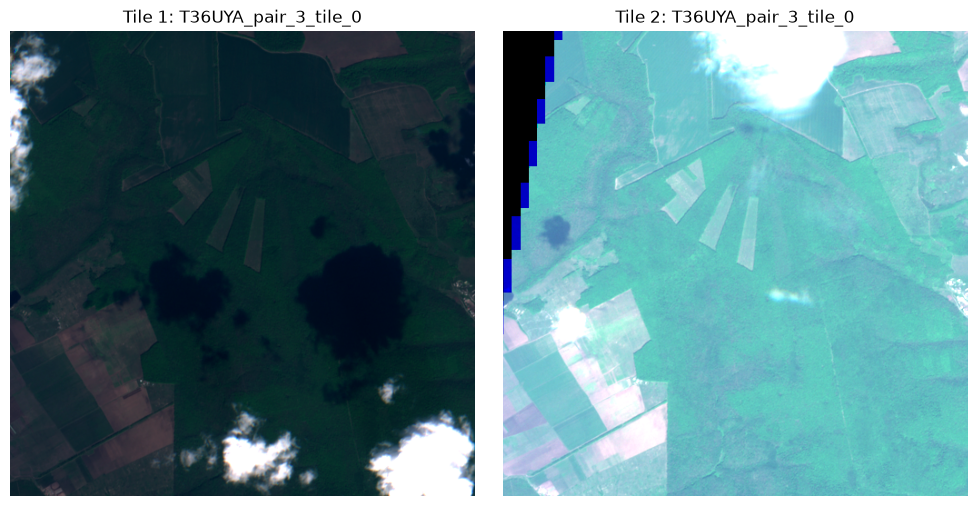

In [42]:
# Visualization of the first saved pair
if len(final_dataset_df) > 0:
    sample = final_dataset_df.iloc[0]
    
    t1 = cv2.cvtColor(cv2.imread(sample['tile1_path']), cv2.COLOR_BGR2RGB)
    t2 = cv2.cvtColor(cv2.imread(sample['tile2_path']), cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(t1)
    axes[0].set_title(f"Tile 1: {sample['tile_pair_id']}")
    axes[0].axis("off")
    
    axes[1].imshow(t2)
    axes[1].set_title(f"Tile 2: {sample['tile_pair_id']}")
    axes[1].axis("off")
    
    plt.tight_layout()
    plt.show()
else:
    print("`final_dataset_df` is empty")